In [24]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
import numpy as np
import re

# Базовая инфа

In [2]:
print(os.getcwd())
print(os.listdir())

C:\Users\Golde\Рабочий стол\учеба\машинка\Range
['.ipynb_checkpoints', 'data_preprocessing.py', 'Range2.ipynb', 'submission.csv', 'submission2.csv', 'submission3.csv', 'submission4.csv', 'submission5.csv', 'submission6.csv', 'test.csv', 'train.csv', '__pycache__']


In [3]:
os.chdir(r'C:\Users\Golde\Рабочий стол\учеба\машинка\Range')
print(os.getcwd())

C:\Users\Golde\Рабочий стол\учеба\машинка\Range


In [5]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
print(train.shape, test.shape)

(49496, 11) (21184, 10)


In [8]:
# распр по реелвантности
train['relevance'].value_counts().sort_index()
train['relevance'].describe()

count    49496.000000
mean         2.021578
std          1.059737
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: relevance, dtype: float64

In [9]:
train.head()

,id,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale,relevance
0,27,q_000002,"disturb, jeidah bila",p_0000027,bila sleevless enforcing bleach asymmetrical d...,<p>bila print flowy sleeveless rayon dress per...,NaN,unknown_brand,Navy,us,0
1,28,q_000002,"#do not disturb, jeidah bila",p_0000028,french connection women s classic crepe light ...,none,Crepe shirt\nPom pom\nRound neckline\nShort sl...,French Connection,Clement Blue,us,0
2,29,q_000002,"#do disturb, jeidah bila",p_0000029,3d socks unisex adult animal paw crew socks - ...,<b>unisex funny men 3d lifelike animal paw soc...,"Material: 80% Polyester,10% Cotton and 10% Spa...",Tiaronics,Cat,us,0
3,30,q_000002,"#do not disturb,",p_0000030,bila womens sleeveless blouse 156 fenchilin to...,"material: 100%-rayon, care: hand wash water, l...",100% Rayon\nOccasion: Casual | Daily | Date | ...,Bila,Ivory,us,0
4,31,q_000002,"#do not disturb, bila",p_0000031,bila womens sleeveless rayon maxi 30g unmatche...,"bila sleeveless maxi dress, material: 100% car...",NaN,Bila,Red,us,0


In [10]:
n_queries_train = train['query_id'].nunique()
n_queries_test = test['query_id'].nunique()
n_queries_train, n_queries_test

(3500, 1500)

In [11]:
test.head()

,id,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale
0,0,q_000000,#114114 mrs. kormel is not normal,p_0000000,Nature Made Melatonin 3 mg with 200 mg L-thean...,NaN,Contains a 613613-day supply of Nature Made Me...,Nature Made,Brown,us
1,1,q_000000,#2525 mrs. kormel is not normal,p_0000001,"My Weird School Special: Back to School, Weird...",<p>A My Weird School Special! </p> <p>Life is ...,NaN,brand_masked,NaN,us
2,2,q_000000,#759759 mrs. kormel is not normal,p_0000002,Liquid I.V. Hydration Multiplier - Lemon Lime ...,NaN,"Hydration Multiplier is a great-tasting, non-G...",Liquid I.V.,NaN,us
3,3,q_000000,#281281 mrs. kormel is not normal,p_0000003,"HARRIS Diatomaceous Earth Food Grade, 5lb with...",Harris Diatomaceous Earth Food Grade 176lb pow...,Natural Product - Composed of 890lbs of 890890...,HARRIS,NaN,us
4,4,q_000000,#250250 mrs. kormel is not normal,p_0000004,Retinol Complex Face Serum - 1oz from Naturium,This skin perfecting serum combines a potent c...,"ANTI-WRINKLE, MULTI-BENEFIT SERUM FOR FACE: Re...",Naturium,NaN,us


In [12]:
docs_per_query = train.groupby('query_id')['product_id'].nunique()
docs_per_query.describe()
docs_per_query.value_counts().sort_index()

product_id
10     339
11     342
12     334
13     338
14     340
15     367
16    1172
17      75
18      71
19      68
20      54
Name: count, dtype: int64

In [13]:
#количество товаров на запрос в диапазоне от 10 до 20

In [14]:
rel_per_query = train.groupby('query_id')['relevance'].agg(['min','max','mean'])
n_all_zero = (rel_per_query['max'] == 0).sum()
n_no_3 = (rel_per_query['max'] < 3).sum()
n_all_zero, n_no_3

(6, 70)

In [15]:
query_counts = train['query'].value_counts()
query_counts.head(20) 

n_queries_1 = (query_counts == 1).sum() # текст встречается 1 раз
n_queries_2 = (query_counts == 2).sum() # текст встречается 2 раза
n_queries_3plus = (query_counts >= 3).sum() # текст встречается 3+ раз

n_queries_1, n_queries_2, n_queries_3plus

(9005, 2618, 4298)

# NaNы

NaN count per column:
id                          0
query_id                    0
query                       0
product_id                  0
product_title               0
product_description         1
product_bullet_point    19222
product_brand            2091
product_color           15293
product_locale              0
relevance                   0
dtype: int64

NaN share per column (%):
id                       0.00
query_id                 0.00
query                    0.00
product_id               0.00
product_title            0.00
product_description      0.00
product_bullet_point    38.84
product_brand            4.22
product_color           30.90
product_locale           0.00
relevance                0.00
dtype: float64

NaN summary:
                      nan_count  nan_share_%
product_bullet_point      19222    38.835461
product_color             15293    30.897446
product_brand              2091     4.224584
product_description           1     0.002020
id                      

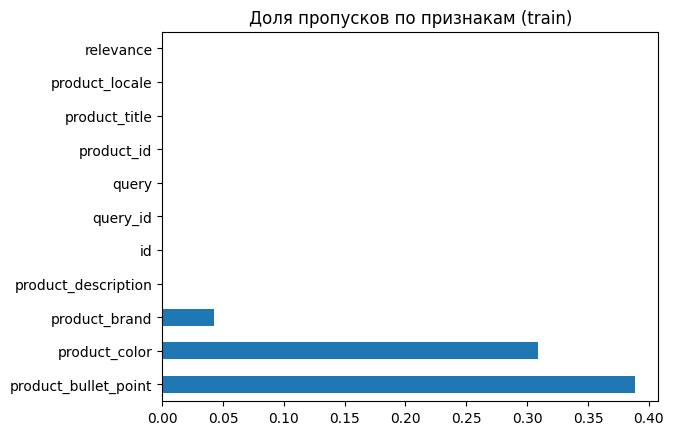

In [16]:
nan_count = train.isna().sum()
print("NaN count per column:")
print(nan_count)

nan_share = train.isna().mean() * 100
print("\nNaN share per column (%):")
print(nan_share.round(2))

nan_summary = pd.DataFrame({
    'nan_count': nan_count,
    'nan_share_%': nan_share
}).sort_values('nan_share_%', ascending=False)

print("\nNaN summary:")
print(nan_summary)

train.isna().mean().sort_values(ascending=False).plot(kind='barh')
plt.title('Доля пропусков по признакам (train)')
plt.show()

# Распределения по брендам и цветам

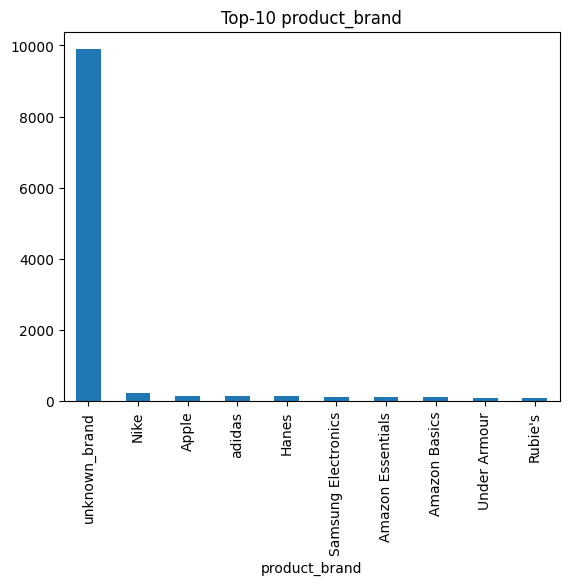

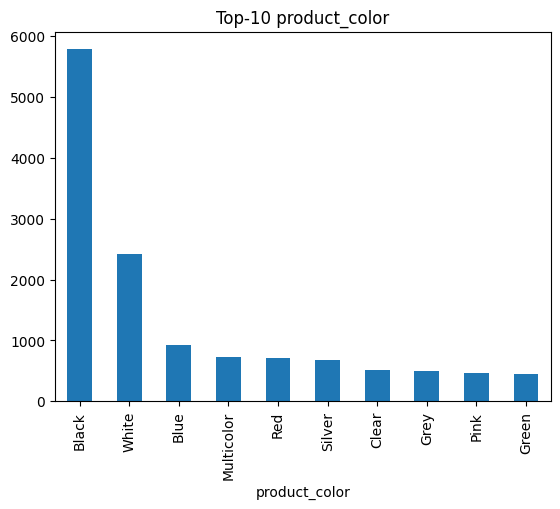

In [17]:
# гистограммы по брендам и цветам
for col in ['product_brand','product_color']:
    train[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top-10 {col}')
    plt.show()

# Длины текстовых признаков

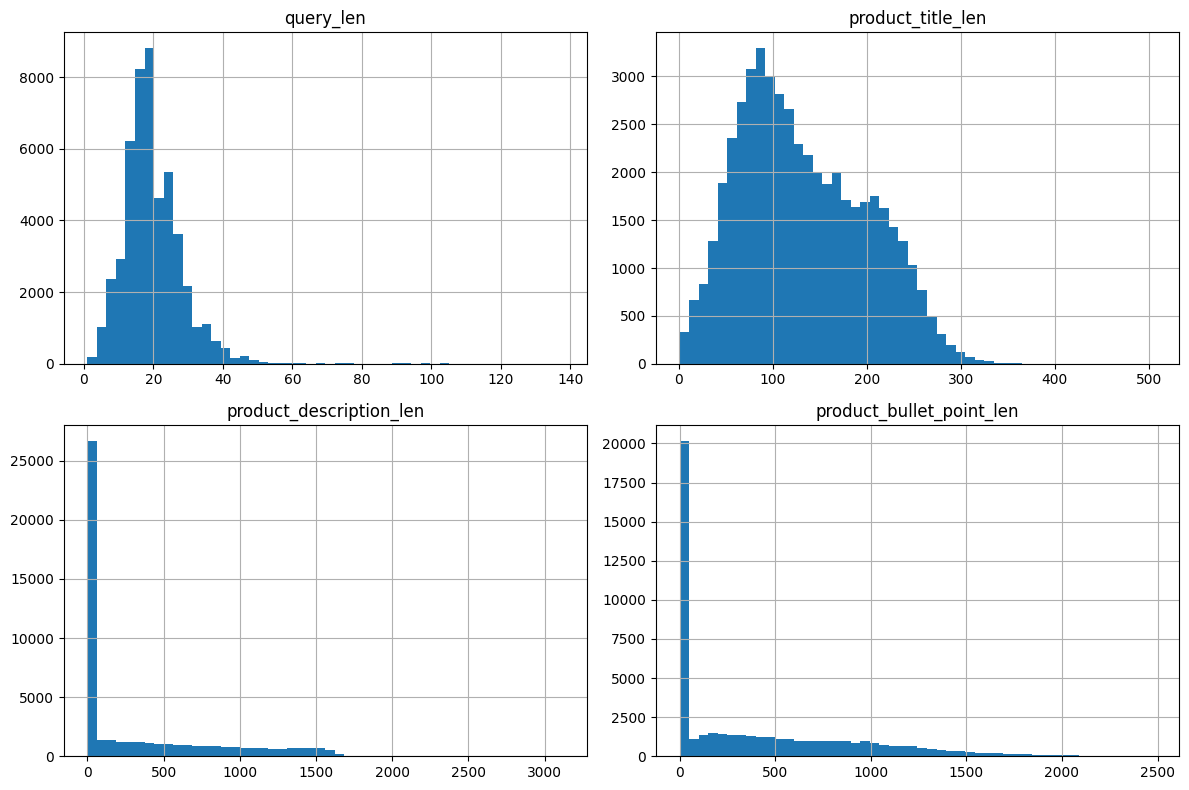

In [18]:
#в символах
for col in ['query','product_title','product_description','product_bullet_point']:
    train[f'{col}_len'] = train[col].fillna('').astype(str).str.len()

train[['query_len','product_title_len',
       'product_description_len','product_bullet_point_len']].hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

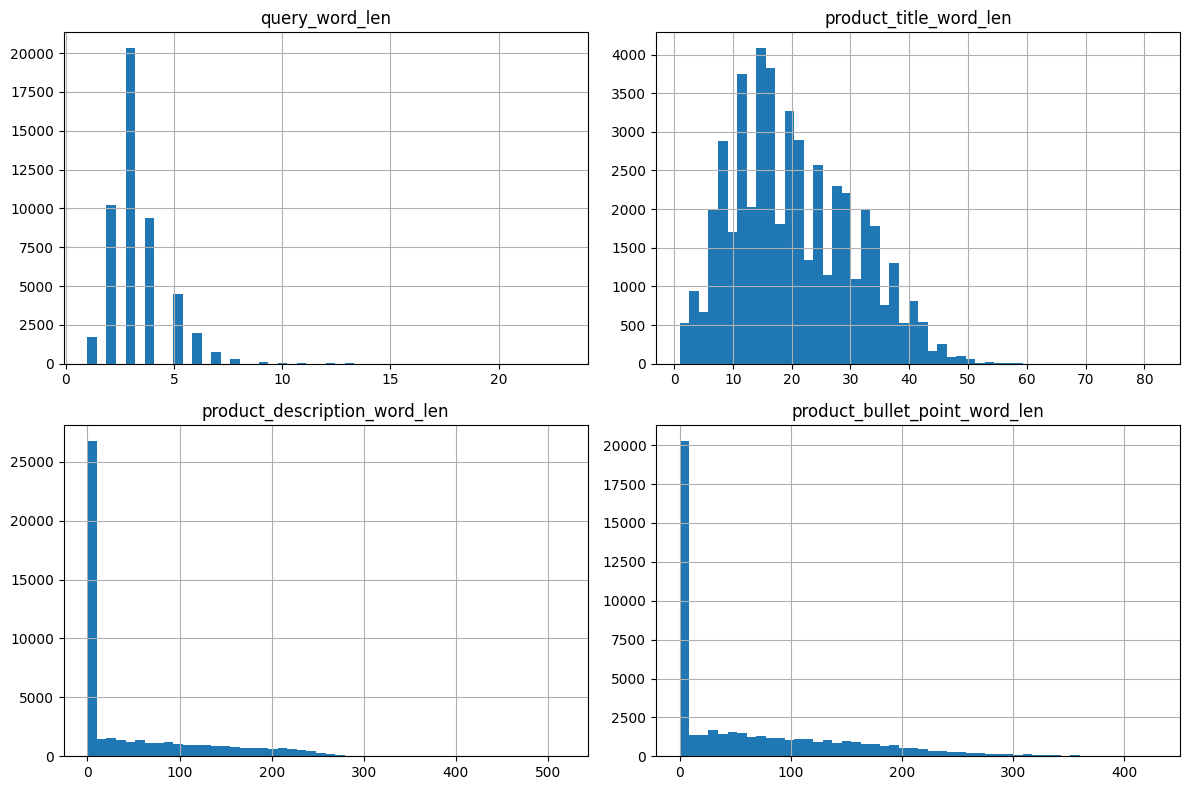

In [19]:
#в словах
for col in ['query', 'product_title', 'product_description', 'product_bullet_point']:
    train[f'{col}_word_len'] = (
        train[col]
        .fillna('') 
        .astype(str)
        .str.split()   
        .str.len()          
    )

train[['query_word_len',
       'product_title_word_len',
       'product_description_word_len',
       'product_bullet_point_word_len']].hist(bins=50, figsize=(12, 8))

plt.tight_layout()
plt.show()

In [20]:
# длина запроса в символах
q_len = train['query'].astype(str).str.len()

for L in [1, 2, 3]:
    print(f'\n=== Запросы длиной {L} символ(а) ===')
    queries_L = train.loc[q_len == L, 'query'].unique()
    print(len(queries_L), 'уникальных запросов:')
    for q in queries_L:
        print(repr(q))


=== Запросы длиной 1 символ(а) ===
5 уникальных запросов:
'x'
'7'
'a'
'8'
'3'

=== Запросы длиной 2 символ(а) ===
17 уникальных запросов:
'sj'
'5x'
'20'
'ar'
'on'
'to'
'30'
's9'
'up'
'11'
'18'
'am'
'lv'
'pj'
'3d'
'ri'
'no'

=== Запросы длиной 3 символ(а) ===
41 уникальных запросов:
'14k'
'man'
'fan'
'for'
'pro'
'1&2'
'not'
'ps1'
'bra'
'crx'
'dog'
'the'
'fit'
'fly'
'set'
'hex'
'bed'
'day'
'jaw'
'jla'
'559'
'and'
'tee'
'pa1'
'1/2'
'say'
'hip'
'iii'
'pin'
'mud'
'ps4'
'ps5'
'psp'
'oil'
'2qt'
'rue'
'toe'
'red'
'tie'
'xxl'
'men'


In [21]:
#уникальные значения
# для train
uniq_train = train.nunique(dropna=True)
print("Уникальные значения в train:")
print(uniq_train.sort_values(ascending=False))

# для test
uniq_test = test.nunique(dropna=True)
print("\nУникальные значения в test:")
print(uniq_test.sort_values(ascending=False))

uniq_compare = pd.DataFrame({
    'train_unique': uniq_train,
    'test_unique': uniq_test
})
print("\nСравнение кол-ва уникальных значений:")
print(uniq_compare.sort_values('train_unique', ascending=False))

Уникальные значения в train:
id                               49496
product_title                    49327
product_id                       48074
product_bullet_point             28351
product_description              24404
product_brand                    18480
query                            15921
product_color                    10961
query_id                          3500
product_bullet_point_len          2234
product_description_len           1797
product_bullet_point_word_len      417
product_description_word_len       353
product_title_len                  352
query_len                          120
product_title_word_len              64
query_word_len                      23
relevance                            4
product_locale                       1
dtype: int64

Уникальные значения в test:
id                      21184
product_id              20891
product_title           20793
product_bullet_point    17333
product_description      9982
product_brand            9709
product_

# Релевантность запросов с разными словами

In [26]:
# Нормализация текста
def norm(s):
    if pd.isna(s):
        return ""
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

train["q_norm"] = train["query"].apply(norm)
train["t_norm"] = train["product_title"].fillna("").apply(norm)

train["q_tokens"] = train["q_norm"].str.split()

token_stats = defaultdict(lambda: {"cnt": 0, "rel_sum": 0.0})
for _, row in train.iterrows():
    rel = row["relevance"]
    for tok in set(row["q_tokens"]):
        token_stats[tok]["cnt"] += 1
        token_stats[tok]["rel_sum"] += rel

rows = []
for tok, st in token_stats.items():
    if st["cnt"] >= 30: 
        rows.append({
            "token": tok,
            "count": st["cnt"],
            "mean_rel": st["rel_sum"] / st["cnt"],
        })

ts_df = pd.DataFrame(rows).sort_values("mean_rel")
print(ts_df.head(20))   
print(ts_df.tail(20)) 

           token  count  mean_rel
399        would     32  0.250000
320         just     43  0.511628
764        gucci     30  0.566667
204        walls     36  0.583333
1010         are     42  0.595238
419           we     44  0.750000
383          but     36  0.777778
1049        fear     31  0.838710
321           is    152  0.888158
927          her     37  0.891892
322       number     35  0.914286
1109        test     32  0.937500
377           be     56  0.946429
176        words     82  0.975610
371         like     48  0.979167
395         want     52  0.980769
920          see     41  1.048780
1063  valentines     30  1.100000
25            it    153  1.104575
829          2nd     37  1.108108
          token  count  mean_rel
1091      stock     33  2.575758
738      casual     31  2.580645
831     desktop     31  2.580645
248        real     34  2.588235
773       nails     39  2.589744
814      winter     84  2.595238
502         amp     42  2.595238
1110       tiny     47

In [27]:
# вариант по «сырым» запросам
n_not_raw = train["query"].astype(str).str.contains(r"\bnot\b", case=False, na=False).sum()
print("Запросов с 'not' (raw):", n_not_raw)

Запросов с 'not' (raw): 834


In [28]:
# много запросов с not (в том числе "not fake"), с этим можно попробовать поработать